# COVID-19 — EDA Dataset Réel
## Analyse exploratoire complète (Covid_Dataset.csv)

Ce notebook remplace l'analyse sur le dataset synthétique dont les features
étaient non-corrélées à la cible (corrélation = 0). Ce dataset contient
**5 434 observations réelles** avec un signal prédictif exploitable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print('OK')

OK


## 1. Chargement et aperçu général

In [5]:
df = pd.read_csv('Covid Dataset.csv')
print(f'Shape : {df.shape}')
print(f'Colonnes : {df.columns.tolist()}')
print()
display(df.head())
print()
print('Valeurs manquantes :', df.isnull().sum().sum())
print('Types :', df.dtypes.value_counts().to_dict())

Shape : (5434, 21)
Colonnes : ['Breathing Problem', 'Fever', 'Dry Cough', 'Sore throat', 'Running Nose', 'Asthma', 'Chronic Lung Disease', 'Headache', 'Heart Disease', 'Diabetes', 'Hyper Tension', 'Fatigue ', 'Gastrointestinal ', 'Abroad travel', 'Contact with COVID Patient', 'Attended Large Gathering', 'Visited Public Exposed Places', 'Family working in Public Exposed Places', 'Wearing Masks', 'Sanitization from Market', 'COVID-19']



,Breathing Problem,Fever,Dry Cough,Sore throat,Running Nose,Asthma,Chronic Lung Disease,Headache,Heart Disease,Diabetes,...,Fatigue,Gastrointestinal,Abroad travel,Contact with COVID Patient,Attended Large Gathering,Visited Public Exposed Places,Family working in Public Exposed Places,Wearing Masks,Sanitization from Market,COVID-19
0,Yes,Yes,Yes,Yes,Yes,No,No,No,No,Yes,...,Yes,Yes,No,Yes,No,Yes,Yes,No,No,Yes
1,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,No,No,...,Yes,No,No,No,Yes,Yes,No,No,No,Yes
2,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,...,Yes,Yes,Yes,No,No,No,No,No,No,Yes
3,Yes,Yes,Yes,No,No,Yes,No,No,Yes,Yes,...,No,No,Yes,No,Yes,Yes,No,No,No,Yes
4,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,...,No,Yes,No,Yes,No,Yes,No,No,No,Yes



Valeurs manquantes : 0
Types : {dtype('O'): 21}


## 2. Encodage Yes/No → 1/0 et nettoyage

Le dataset contient des chaînes 'Yes'/'No'. On encode en binaire 1/0.
Deux colonnes constantes (`Wearing Masks`, `Sanitization from Market`) sont retirées
car elles n'apportent aucune information discriminante.

In [6]:
df_enc = df.copy()
for col in df.columns:
    df_enc[col] = (df[col].str.strip() == 'Yes').astype(int)

# Retirer les colonnes constantes (variance = 0)
constant_cols = [c for c in df_enc.columns if df_enc[c].std() == 0]
print(f'Colonnes constantes supprimées : {constant_cols}')
df_enc = df_enc.drop(columns=constant_cols)

FEATURES = [c for c in df_enc.columns if c != 'COVID-19']
X = df_enc[FEATURES]
y = df_enc['COVID-19']

print(f'Features finales ({len(FEATURES)}) : {FEATURES}')
display(df_enc.head())

Colonnes constantes supprimées : ['Wearing Masks', 'Sanitization from Market']
Features finales (18) : ['Breathing Problem', 'Fever', 'Dry Cough', 'Sore throat', 'Running Nose', 'Asthma', 'Chronic Lung Disease', 'Headache', 'Heart Disease', 'Diabetes', 'Hyper Tension', 'Fatigue ', 'Gastrointestinal ', 'Abroad travel', 'Contact with COVID Patient', 'Attended Large Gathering', 'Visited Public Exposed Places', 'Family working in Public Exposed Places']


,Breathing Problem,Fever,Dry Cough,Sore throat,Running Nose,Asthma,Chronic Lung Disease,Headache,Heart Disease,Diabetes,Hyper Tension,Fatigue,Gastrointestinal,Abroad travel,Contact with COVID Patient,Attended Large Gathering,Visited Public Exposed Places,Family working in Public Exposed Places,COVID-19
0,1,1,1,1,1,0,0,0,0,1,1,1,1,0,1,0,1,1,1
1,1,1,1,1,0,1,1,1,0,0,0,1,0,0,0,1,1,0,1
2,1,1,1,1,1,1,1,1,0,1,0,1,1,1,0,0,0,0,1
3,1,1,1,0,0,1,0,0,1,1,0,0,0,1,0,1,1,0,1
4,1,1,1,1,1,0,1,1,1,1,1,0,1,0,1,0,1,0,1


## 3. Distribution de la cible

Distribution COVID-19 :
COVID-19
1    4383
0    1051
Name: count, dtype: int64
COVID-19
1    0.807
0    0.193
Name: proportion, dtype: float64


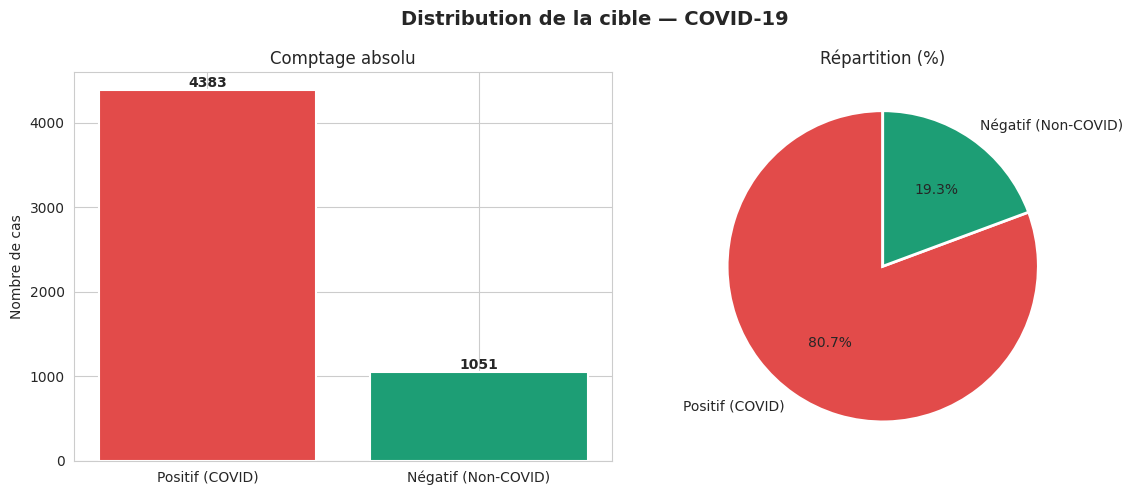

In [7]:
print('Distribution COVID-19 :')
print(y.value_counts())
print(y.value_counts(normalize=True).round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribution de la cible — COVID-19', fontweight='bold', fontsize=14)

counts = y.value_counts()
labels = ['Positif (COVID)', 'Négatif (Non-COVID)']
colors = ['#E24B4A', '#1D9E75']

axes[0].bar(labels, [counts[1], counts[0]], color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Comptage absolu')
axes[0].set_ylabel('Nombre de cas')
for i, v in enumerate([counts[1], counts[0]]):
    axes[0].text(i, v + 40, str(v), ha='center', fontweight='bold')

axes[1].pie([counts[1], counts[0]], labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Répartition (%)')

plt.tight_layout()
plt.savefig('eda_01_target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Impact de chaque feature sur le diagnostic

On mesure la différence de taux de présence entre les patients COVID+ et COVID-.
Une valeur élevée signifie que la feature est fortement discriminante.

Différence de taux (COVID+ minus COVID-) :
Chronic Lung Disease                      -0.0718
Fatigue                                   -0.0559
Headache                                  -0.0352
Running Nose                              -0.0071
Gastrointestinal                          -0.0043
Heart Disease                              0.0342
Diabetes                                   0.0514
Asthma                                     0.1135
Hyper Tension                              0.1298
Visited Public Exposed Places              0.1515
Family working in Public Exposed Places    0.1999
Fever                                      0.3662
Contact with COVID Patient                 0.4521
Dry Cough                                  0.4766
Attended Large Gathering                   0.4925
Breathing Problem                          0.5298
Abroad travel                              0.5592
Sore throat                                0.5669
dtype: float64


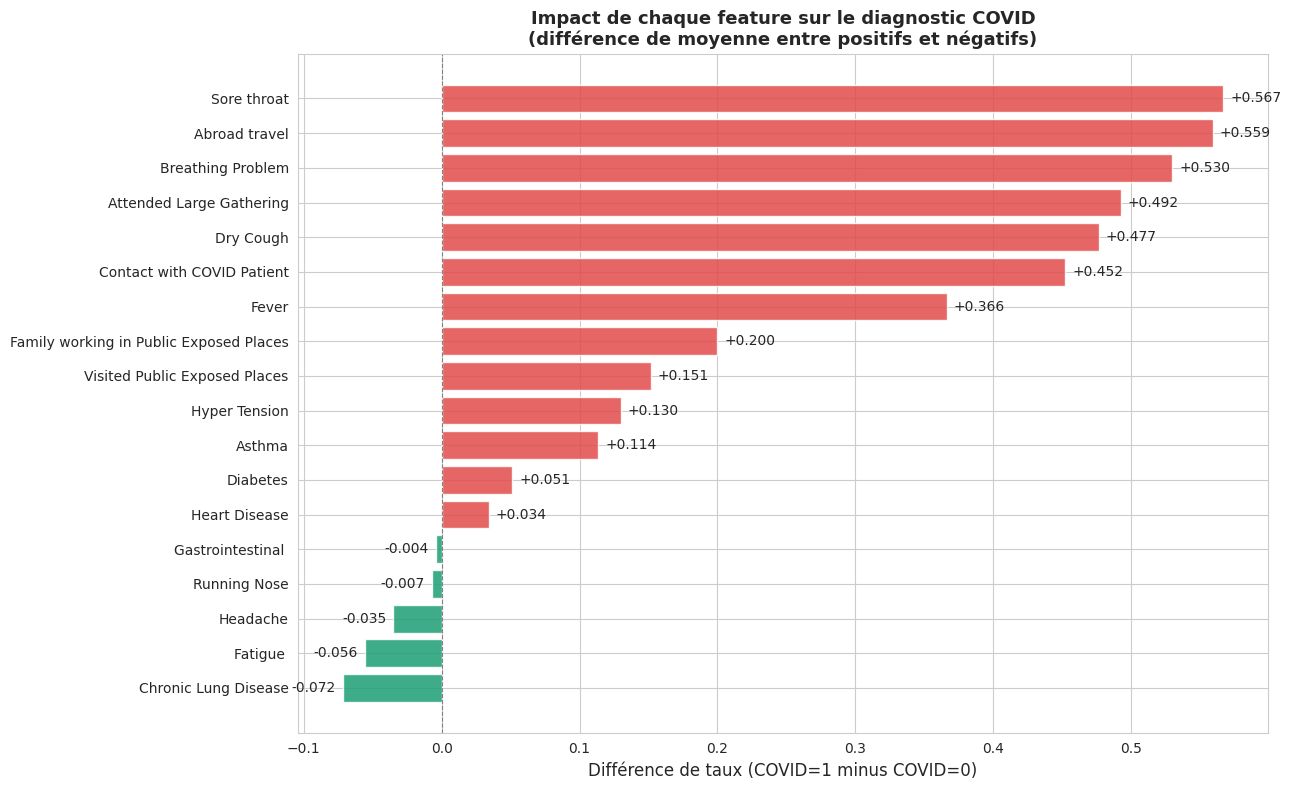

In [8]:
pos_rate = df_enc.groupby('COVID-19')[FEATURES].mean()
diff = (pos_rate.loc[1] - pos_rate.loc[0]).sort_values()

print('Différence de taux (COVID+ minus COVID-) :')
print(diff.round(4))

fig, ax = plt.subplots(figsize=(13, 8))
colors_bar = ['#E24B4A' if v > 0 else '#1D9E75' for v in diff]
bars = ax.barh(diff.index, diff.values, color=colors_bar, alpha=0.85)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Différence de taux (COVID=1 minus COVID=0)', fontsize=12)
ax.set_title('Impact de chaque feature sur le diagnostic COVID\n(différence de moyenne entre positifs et négatifs)',
             fontweight='bold', fontsize=13)
for bar, val in zip(bars, diff.values):
    ax.text(val + 0.005 if val >= 0 else val - 0.005,
            bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=10)
plt.tight_layout()
plt.savefig('eda_02_feature_impact.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Matrice de corrélation

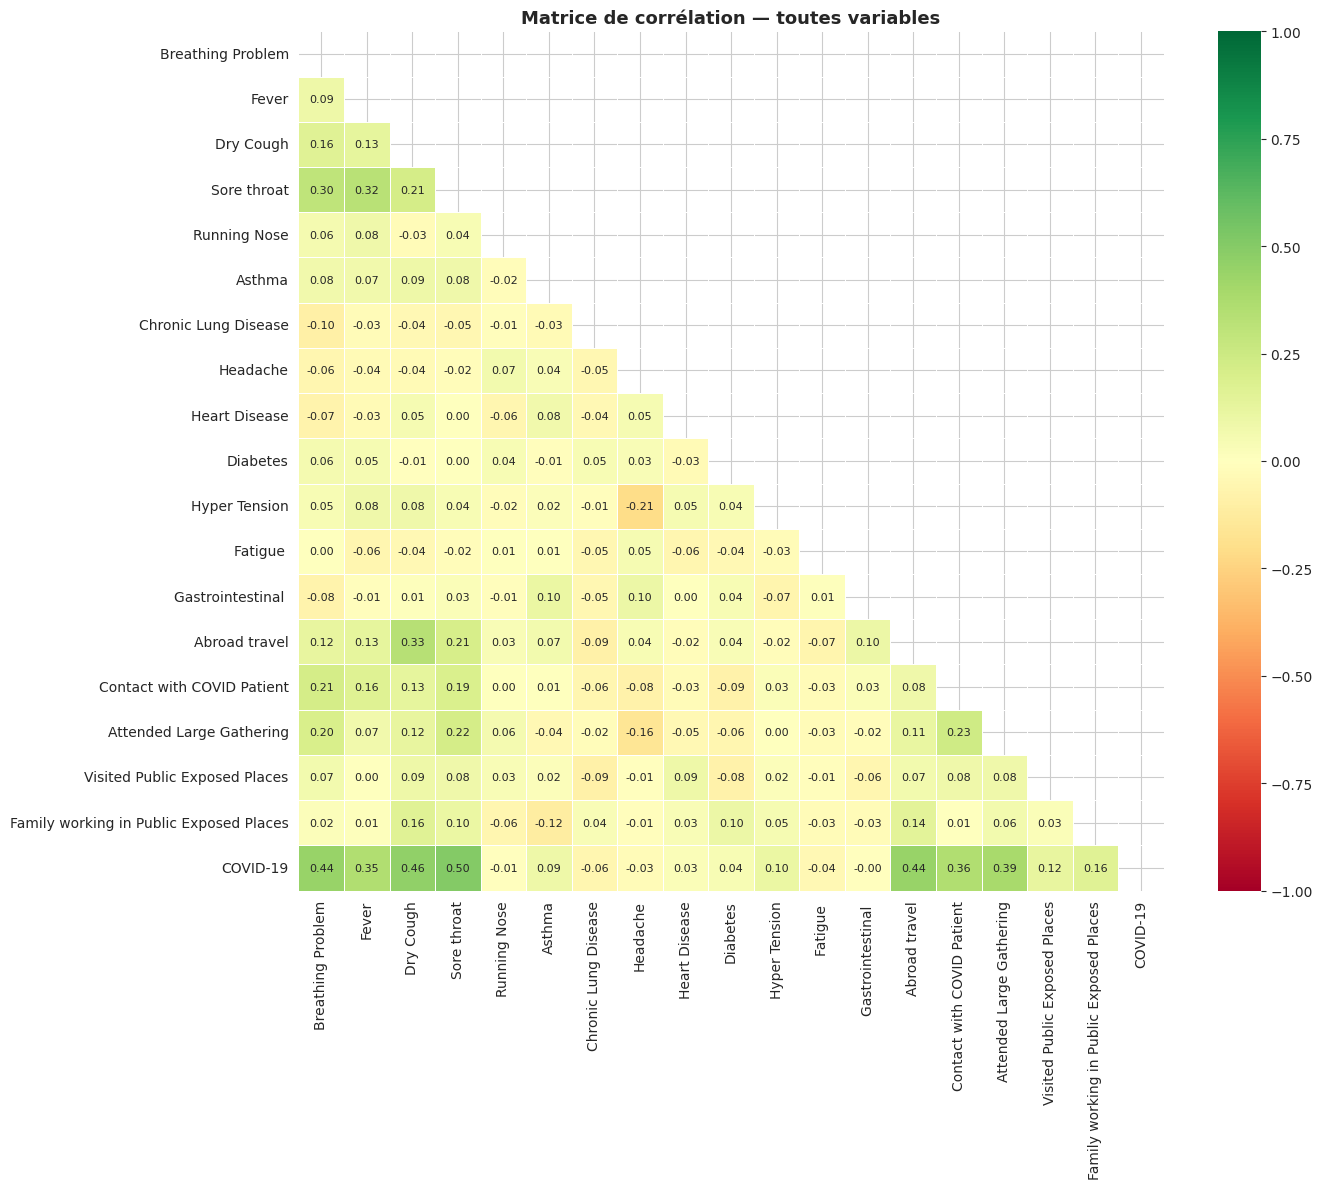

In [9]:
fig, ax = plt.subplots(figsize=(14, 12))
corr_matrix = df_enc[FEATURES + ['COVID-19']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Matrice de corrélation — toutes variables', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('eda_03_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Top 7 features discriminantes

Top 7 features : ['Sore throat', 'Abroad travel', 'Breathing Problem', 'Attended Large Gathering', 'Dry Cough', 'Contact with COVID Patient', 'Fever']


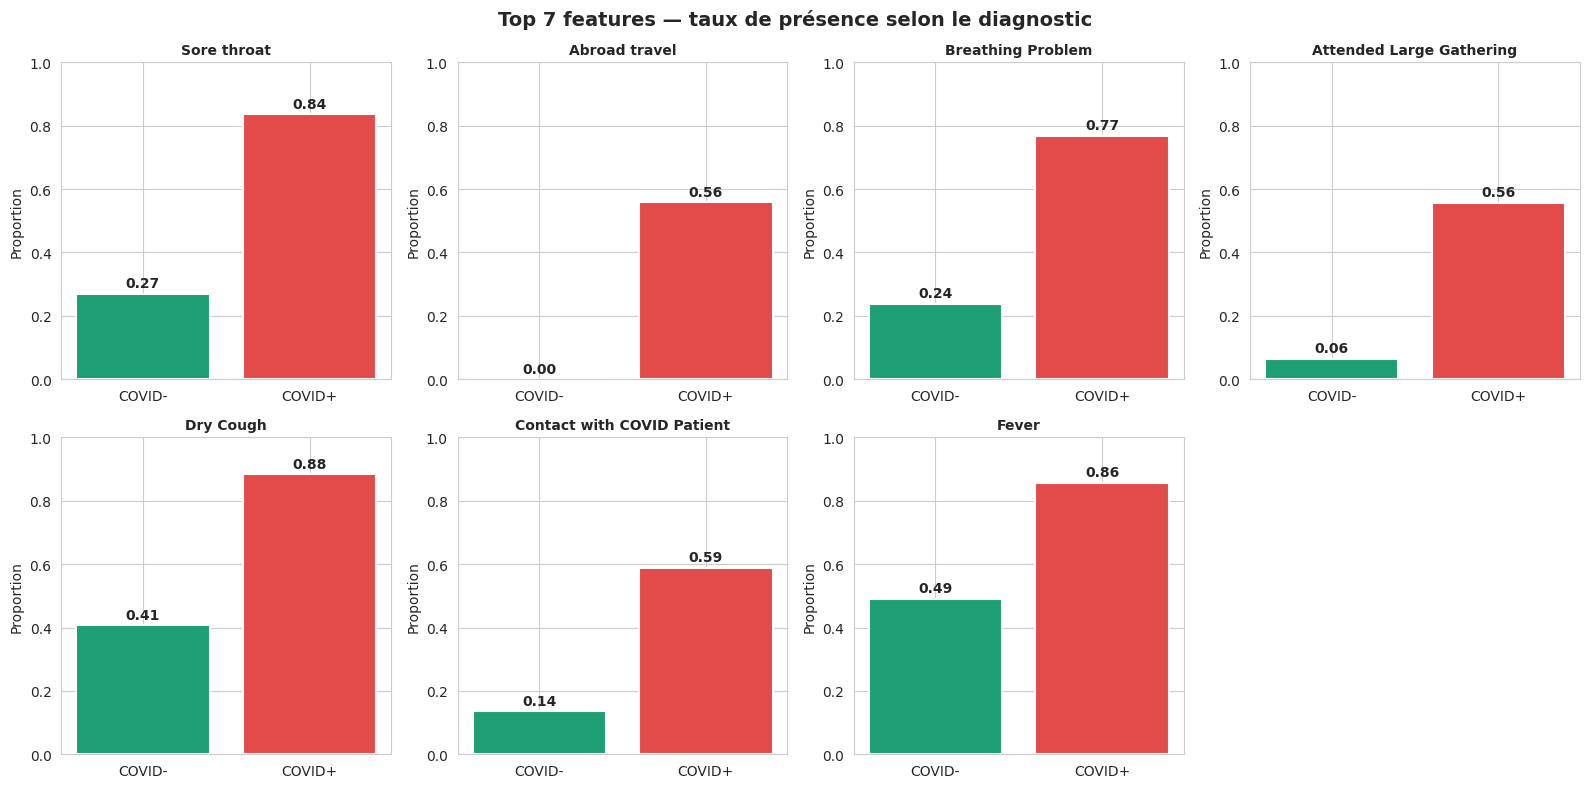

In [10]:
top_features = diff.abs().sort_values(ascending=False).head(7).index.tolist()
print('Top 7 features :', top_features)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Top 7 features — taux de présence selon le diagnostic', fontweight='bold', fontsize=14)
axes = axes.ravel()

for i, feat in enumerate(top_features):
    rate_neg = df_enc[df_enc['COVID-19'] == 0][feat].mean()
    rate_pos = df_enc[df_enc['COVID-19'] == 1][feat].mean()
    axes[i].bar(['COVID-', 'COVID+'], [rate_neg, rate_pos],
                color=['#1D9E75', '#E24B4A'], edgecolor='white', linewidth=1.5)
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].set_ylim(0, 1)
    axes[i].set_ylabel('Proportion')
    for j, v in enumerate([rate_neg, rate_pos]):
        axes[i].text(j, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold', fontsize=10)

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('eda_04_top_features.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Profil symptomatique moyen COVID+ vs COVID−

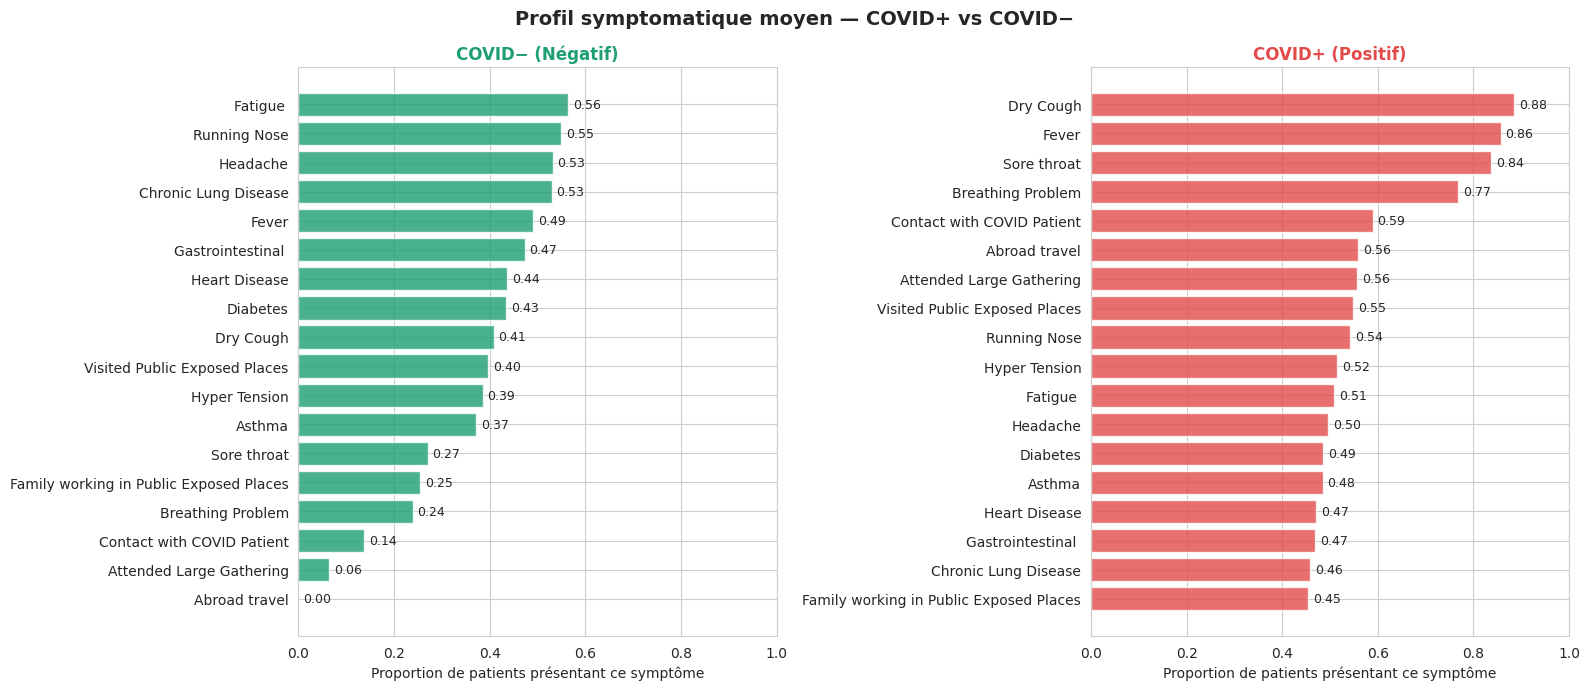

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Profil symptomatique moyen — COVID+ vs COVID−', fontweight='bold', fontsize=14)

for ax, label, color, val in zip(axes,
    ['COVID− (Négatif)', 'COVID+ (Positif)'],
    ['#1D9E75', '#E24B4A'], [0, 1]):
    rates = df_enc[df_enc['COVID-19'] == val][FEATURES].mean().sort_values()
    bars = ax.barh(rates.index, rates.values, color=color, alpha=0.8)
    ax.set_xlim(0, 1)
    ax.set_xlabel('Proportion de patients présentant ce symptôme')
    ax.set_title(label, fontsize=12, fontweight='bold', color=color)
    for bar, v in zip(bars, rates.values):
        ax.text(v + 0.01, bar.get_y() + bar.get_height()/2,
                f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_05_profiles.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Corrélations avec la cible — synthèse

**Conclusion EDA :**
- Dataset réel : 5 434 observations, 18 features binaires utilisables
- Déséquilibre classes : 80.7% COVID+ vs 19.3% COVID− → nécessite `class_weight='balanced'`
- Signal fort : corrélation jusqu'à 0.50 (Sore throat, Dry Cough, Abroad travel)
- 2 colonnes constantes supprimées (Wearing Masks, Sanitization from Market)
- Aucune valeur manquante
- Ce dataset est adapté à la classification supervisée, contrairement au dataset synthétique précédent

In [12]:
corr_target = X.corrwith(y).abs().sort_values(ascending=False)
print('=== Corrélation features → COVID-19 ===')
print(corr_target.round(4))

print()
print('=== Résumé EDA ===')
print(f'Observations totales  : {len(df)}')
print(f'Features utilisables  : {len(FEATURES)}')
print(f'COVID+ (classe 1)     : {y.sum()} ({y.mean()*100:.1f}%)')
print(f'COVID- (classe 0)     : {(y==0).sum()} ({(y==0).mean()*100:.1f}%)')
print(f'Valeurs manquantes    : {df_enc.isnull().sum().sum()}')
print(f'Signal prédictif      : OUI (corr max = {corr_target.max():.4f})')

# Sauvegarder le dataset encodé pour le notebook de classification
import pickle
eda_data = {'df_enc': df_enc, 'FEATURES': FEATURES, 'X': X, 'y': y}
with open('eda_data.pkl', 'wb') as f:
    pickle.dump(eda_data, f)
print('\n-> [OK] eda_data.pkl sauvegardé pour le notebook de classification')

=== Corrélation features → COVID-19 ===
Sore throat                                0.5028
Dry Cough                                  0.4643
Abroad travel                              0.4439
Breathing Problem                          0.4438
Attended Large Gathering                   0.3901
Contact with COVID Patient                 0.3571
Fever                                      0.3529
Family working in Public Exposed Places    0.1602
Visited Public Exposed Places              0.1198
Hyper Tension                              0.1026
Asthma                                     0.0899
Chronic Lung Disease                       0.0568
Fatigue                                    0.0442
Diabetes                                   0.0406
Headache                                   0.0278
Heart Disease                              0.0271
Running Nose                               0.0057
Gastrointestinal                           0.0034
dtype: float64

=== Résumé EDA ===
Observations totales  : 5